<a href="https://colab.research.google.com/github/Vronska-Anhelina/-Prediction-and-Clustering-Models/blob/main/Seasonality_of_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
data = pd.DataFrame({
    "Date": pd.date_range(start="2019-01-01", end="2021-12-31", freq="ME"),
    "Promotion_Spend": [300, 250, 400, 350, 450, 300, 200, 220, 270, 320, 300, 380] * 3,
    "Demand": [800, 750, 900, 850, 950, 780, 700, 720, 770, 810, 800, 880] +
              [820, 760, 920, 860, 960, 790, 710, 730, 780, 820, 810, 890] +
              [810, 740, 910, 840, 950, 770, 690, 710, 760, 800, 790, 870]
})
data.head()

,Date,Promotion_Spend,Demand
0,2019-01-31,300,800
1,2019-02-28,250,750
2,2019-03-31,400,900
3,2019-04-30,350,850
4,2019-05-31,450,950


R2: 0.9562718198735793


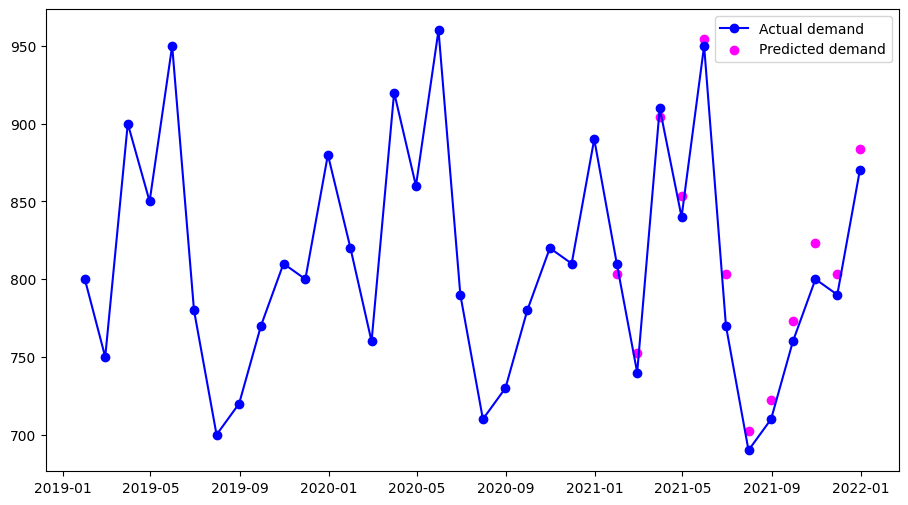

In [ ]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
X = data[["Promotion_Spend"]]
y = data["Demand"]
X_train, X_test, y_train, y_test = X[:24], X[-12:], y[:24], y[-12:]
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("R2:", r2_score(y_test, y_pred))

plt.figure(figsize=(11, 6))
plt.plot(data["Date"], data["Demand"], color="blue", marker="o", label="Actual demand")
plt.scatter(data["Date"][X_test.index], y_pred, color="magenta", label="Predicted demand")
plt.legend()
plt.show()

We see that the linear model is not bad, it almost accurately predicts demand. With r2 score 95%.

In [ ]:
import numpy as np

data["month"]=data["Date"].dt.month
data=pd.get_dummies(data,columns=["month"],drop_first=True)
data["sine"]=np.sin(2*np.pi*data["Date"].dt.month/12)
data["cosine"]=np.cos(2*np.pi*data["Date"].dt.month/12)
data["is_holiday"]=(data["Date"].dt.month==12)

data.head()

,Date,Promotion_Spend,Demand,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,sine,cosine,is_holiday
0,2019-01-31,300,800,False,False,False,False,False,False,False,False,False,False,False,0.500000,8.660254e-01,False
1,2019-02-28,250,750,True,False,False,False,False,False,False,False,False,False,False,0.866025,5.000000e-01,False
2,2019-03-31,400,900,False,True,False,False,False,False,False,False,False,False,False,1.000000,6.123234e-17,False
3,2019-04-30,350,850,False,False,True,False,False,False,False,False,False,False,False,0.866025,-5.000000e-01,False
4,2019-05-31,450,950,False,False,False,True,False,False,False,False,False,False,False,0.500000,-8.660254e-01,False


In [ ]:
from sklearn.linear_model import LinearRegression
X=data.loc[:,"month_2":"is_holiday"]
y=data["Demand"]
X_train,X_test,y_train,y_test=X[:24],X[-12:],y[:24],y[-12:]
model= LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

R2 score:0.9696146245059287


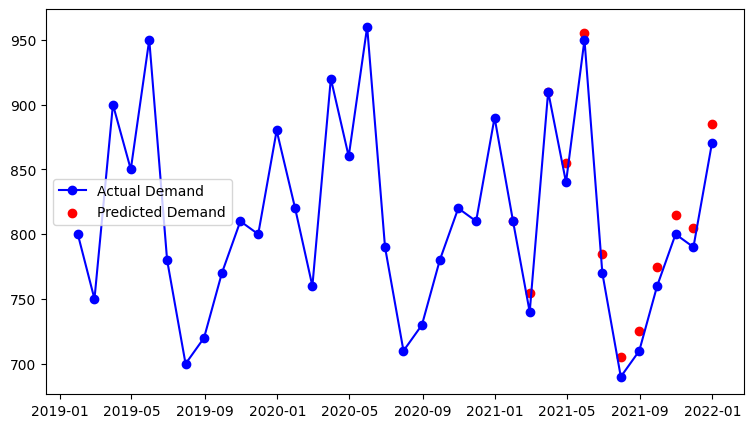

In [ ]:
y_pred=model.predict(X_test)
print(f"R2 score:{r2_score(y_test,y_pred)}")
plt.figure(figsize=(9,5))
plt.plot(data["Date"],data["Demand"],color="blue",marker="o",label="Actual Demand")
plt.scatter(data["Date"][X_test.index],y_pred,color="red",label="Predicted Demand")
plt.legend()
plt.show()

We see an improvement in the r2 score to 96% and in the graph we see that the model almost perfectly predicts demand, better than the previous one.